# DSI Assignment 3 - Toronto Crime Data Visualization

Download, clean, and visualize Toronto neighbourhood crime data

In [1]:
# imports
import requests
import polars as pl
import matplotlib.pyplot as plt

## Download data

In [2]:
# Toronto Open Data is stored in a CKAN instance. It's APIs are documented here:
# [https://docs.ckan.org/en/latest/api/]

# To hit our API, you'll be making requests to:
base_url = "https://ckan0.cf.opendata.inter.prod-toronto.ca"

# Datasets are called "packages". Each package can contain many "resources"
# To retrieve the metadata for this package and its resources, use the package name in this page's URL:
url = base_url + "/api/3/action/package_show"

# Crime package
params_crime = {"id": "neighbourhood-crime-rates"}
package_crime = requests.get(url, params=params_crime).json()

# To get resource data for crime:
for idx, resource in enumerate(package_crime["result"]["resources"]):
    # for datastore_active resources:
    if resource["datastore_active"]:
        # To get all records in CSV format:
        c_url = base_url + "/datastore/dump/" + resource["id"]
        resource_dump_data = requests.get(c_url).text
        # Save string data to CSV file
        # [https://docs.python.org/3/library/functions.html#open]
        with open("02_activities/assignments/data/neighbourhood_crime.csv", "w", encoding="utf-8") as f:
            f.write(resource_dump_data)

## Clean data

In [3]:
# load raw data
crime_df = pl.read_csv("02_activities/assignments/data/neighbourhood_crime.csv")

In [4]:
# select columns of interest
crime_df = crime_df.select(
    "AREA_NAME",
    "ASSAULT_2019", "ASSAULT_RATE_2019",
    "ASSAULT_2020", "ASSAULT_RATE_2020",
    "ASSAULT_2021", "ASSAULT_RATE_2021",
    "ASSAULT_2022", "ASSAULT_RATE_2022",
    "ASSAULT_2023", "ASSAULT_RATE_2023",
    "ASSAULT_2024", "ASSAULT_RATE_2024",
    "BREAKENTER_2019", "BREAKENTER_RATE_2019",
    "BREAKENTER_2020", "BREAKENTER_RATE_2020",
    "BREAKENTER_2021", "BREAKENTER_RATE_2021",
    "BREAKENTER_2022", "BREAKENTER_RATE_2022",
    "BREAKENTER_2023", "BREAKENTER_RATE_2023",
    "BREAKENTER_2024", "BREAKENTER_RATE_2024",
    "HOMICIDE_2019", "HOMICIDE_RATE_2019",
    "HOMICIDE_2020", "HOMICIDE_RATE_2020",
    "HOMICIDE_2021", "HOMICIDE_RATE_2021",
    "HOMICIDE_2022", "HOMICIDE_RATE_2022",
    "HOMICIDE_2023", "HOMICIDE_RATE_2023",
    "HOMICIDE_2024", "HOMICIDE_RATE_2024",
    "ROBBERY_2019", "ROBBERY_RATE_2019",
    "ROBBERY_2020", "ROBBERY_RATE_2020",
    "ROBBERY_2021", "ROBBERY_RATE_2021",
    "ROBBERY_2022", "ROBBERY_RATE_2022",
    "ROBBERY_2023", "ROBBERY_RATE_2023",
    "ROBBERY_2024", "ROBBERY_RATE_2024",
    "SHOOTING_2019", "SHOOTING_RATE_2019",
    "SHOOTING_2020", "SHOOTING_RATE_2020",
    "SHOOTING_2021", "SHOOTING_RATE_2021",
    "SHOOTING_2022", "SHOOTING_RATE_2022",
    "SHOOTING_2023", "SHOOTING_RATE_2023",
    "SHOOTING_2024", "SHOOTING_RATE_2024",
)

In [5]:
# rename and normalize neighbourhood column
clean_df = crime_df.rename({"AREA_NAME": "neighbourhood"})
clean_df = clean_df.with_columns(
    pl.col("neighbourhood")
    .str.normalize(form="NFKC")
    .str.strip_chars(" ")
    .str.replace_all("`", "'")
    .str.replace_all(r"\s+", "-")
    .str.replace_all(r"\.", "")
    .str.to_lowercase()
)

In [6]:
# fill missing rate values with 0
rate_cols = [c for c in clean_df.columns if "_RATE_" in c]
clean_df = clean_df.with_columns(
    [pl.col(c).fill_null(0.0).alias(c) for c in rate_cols]
)

# lowercase all column names
clean_df = clean_df.rename({c: c.lower() for c in clean_df.columns})
clean_df

neighbourhood,assault_2019,assault_rate_2019,assault_2020,assault_rate_2020,assault_2021,assault_rate_2021,assault_2022,assault_rate_2022,assault_2023,assault_rate_2023,assault_2024,assault_rate_2024,breakenter_2019,breakenter_rate_2019,breakenter_2020,breakenter_rate_2020,breakenter_2021,breakenter_rate_2021,breakenter_2022,breakenter_rate_2022,breakenter_2023,breakenter_rate_2023,breakenter_2024,breakenter_rate_2024,homicide_2019,homicide_rate_2019,homicide_2020,homicide_rate_2020,homicide_2021,homicide_rate_2021,homicide_2022,homicide_rate_2022,homicide_2023,homicide_rate_2023,homicide_2024,homicide_rate_2024,robbery_2019,robbery_rate_2019,robbery_2020,robbery_rate_2020,robbery_2021,robbery_rate_2021,robbery_2022,robbery_rate_2022,robbery_2023,robbery_rate_2023,robbery_2024,robbery_rate_2024,shooting_2019,shooting_rate_2019,shooting_2020,shooting_rate_2020,shooting_2021,shooting_rate_2021,shooting_2022,shooting_rate_2022,shooting_2023,shooting_rate_2023,shooting_2024,shooting_rate_2024
str,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64
"""south-eglinton-davisville""",62,270.683258,74,309.701172,106,427.833374,122,474.394379,100,368.745148,123,434.368042,83,362.366302,69,288.775421,44,177.591217,24,93.323486,43,158.560425,52,183.635269,1,4.365859,1,4.185151,1,4.036164,null,0.0,null,0.0,null,0.0,5,21.829294,16,66.962418,9,36.325478,15,58.327175,3,11.062355,16,56.503162,null,0.0,1,4.185151,null,0.0,1,3.888479,null,0.0,2,7.062895
"""north-toronto""",84,561.760193,80,501.284546,118,700.504578,136,766.369873,105,554.177429,128,640.160034,36,240.754364,89,557.679077,49,290.887512,48,270.48349,31,163.614288,31,155.038757,1,6.687621,1,6.266057,null,0.0,null,0.0,null,0.0,null,0.0,19,127.064804,3,18.79817,12,71.237755,12,67.620872,14,73.890327,18,90.022507,1,6.687621,null,0.0,1,5.93648,1,5.635073,null,0.0,1,5.00125
"""dovercourt-village""",113,841.149353,91,685.602356,115,878.801758,103,786.80011,104,783.84082,118,883.762756,83,617.835327,47,354.102325,19,145.193329,33,252.081589,46,346.698822,45,337.028168,2,14.887599,1,7.534092,null,0.0,null,0.0,null,0.0,null,0.0,17,126.544586,16,120.545471,22,168.118607,14,106.943703,21,158.275543,12,89.874176,null,0.0,null,0.0,2,15.283509,null,0.0,1,7.536931,2,14.97903
"""junction-wallace-emerson""",186,743.345825,171,685.343262,182,734.670837,138,541.367554,230,864.661682,195,709.194092,103,411.637756,110,440.864105,76,306.785614,56,219.685379,82,308.270691,77,280.040741,1,3.996483,null,0.0,null,0.0,null,0.0,null,0.0,null,0.0,32,127.887459,23,92.180672,11,44.403179,20,78.459061,18,67.669174,12,43.642712,2,7.992966,4,16.031422,4,16.146612,3,11.76886,2,7.518797,null,0.0
"""yonge-bay-corridor""",660,5015.197754,377,2785.165527,325,2345.38501,441,3042.218506,543,3523.686035,554,3416.800293,119,904.25531,148,1093.380615,112,808.255737,123,848.509949,108,700.843628,95,585.913391,2,15.197568,null,0.0,1,7.216569,1,6.898455,1,6.489293,1,6.16751,63,478.723419,55,406.323883,50,360.828461,55,379.415009,60,389.357574,65,400.888123,4,30.395136,2,14.775414,null,0.0,1,6.898455,2,12.978585,1,6.16751
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""west-humber-clairville""",255,716.191528,248,696.179443,242,681.248779,264,733.883728,322,872.014282,347,923.609253,135,379.160217,111,311.596436,98,275.877594,136,378.06131,212,574.121216,155,412.563202,2,5.617188,2,5.61435,1,2.815078,1,2.779863,2,5.416238,1,2.661698,72,202.218796,76,213.345306,53,149.199112,70,194.590393,77,208.525162,64,170.348679,14,39.32032,5,14.035875,5,14.075388,5,13.899313,9,24.37307,7,18.631887
"""black-creek""",216,952.590942,269,1192.851807,212,949.480469,243,1078.514038,230,996.792908,266,1135.442017,38,167.585449,25,110.859825,27,120.9244,33,146.464874,29,125.682587,21,89.6401

## Visualization 1 - Bar Chart
Total crime counts by type for 2024

In [7]:
# prepare data - sum 2024 counts across all neighbourhoods
crime_types = ["assault", "breakenter", "homicide", "robbery", "shooting"]
crime_labels = ["Assault", "Break & Enter", "Homicide", "Robbery", "Shooting"]

totals = []
for crime in crime_types:
    col_name = f"{crime}_2024"
    total = clean_df.select(pl.col(col_name).sum()).item()
    totals.append(total)

totals

[25431, 6824, 85, 3149, 461]

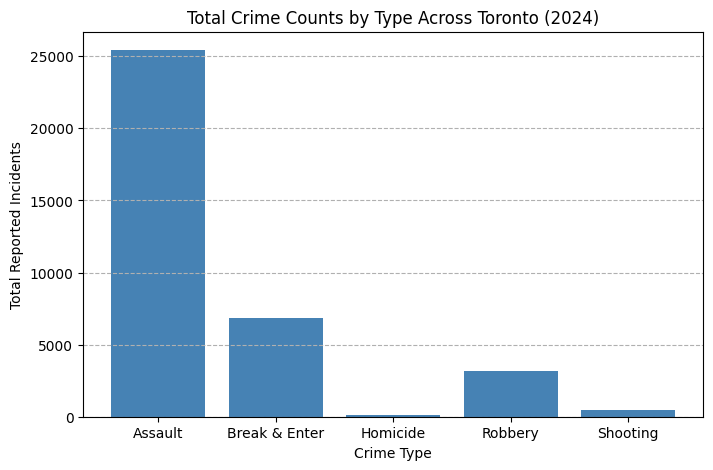

In [8]:
# bar chart
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(crime_labels, totals, color="steelblue")
ax.set_title("Total Crime Counts by Type Across Toronto (2024)")
ax.set_xlabel("Crime Type")
ax.set_ylabel("Total Reported Incidents")
ax.grid(axis="y", linestyle="--")

## Visualization 2 - Line chart (see R script as well)
Average assault rate trend from 2019 to 2024

In [9]:
# prepare data - mean assault rate across all neighbourhoods per year
years = [2019, 2020, 2021, 2022, 2023, 2024]

mean_rates = []
for year in years:
    col_name = f"assault_rate_{year}"
    mean_rate = clean_df.select(pl.col(col_name).mean()).item()
    mean_rates.append(mean_rate)

mean_rates

[695.5150554994997,
 597.5351185859006,
 630.5278763589982,
 685.5982082704958,
 765.8837919597388,
 778.4544111807139]

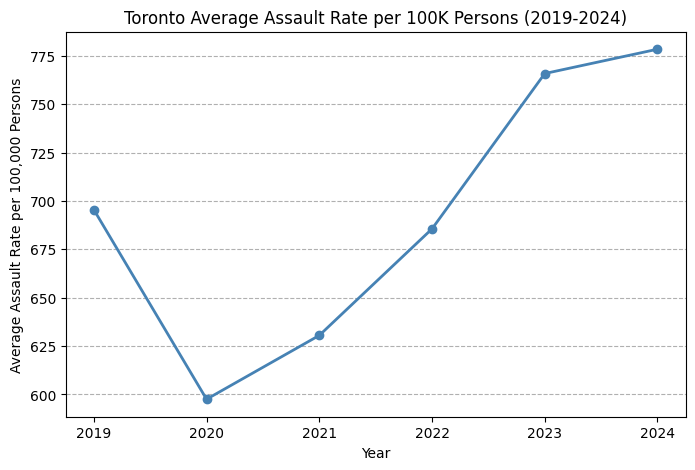

In [10]:
# line chart
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(years, mean_rates, marker="o", color="steelblue", linewidth=2)
ax.set_title("Toronto Average Assault Rate per 100K Persons (2019-2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Average Assault Rate per 100,000 Persons")
ax.grid(axis="y", linestyle="--")